<a href="https://colab.research.google.com/github/cpalma-dev/BigData/blob/main/Equipo_53_semanas_4_y_5_v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Maestría en Inteligencia Artificial Aplicada**

## Curso: **Procesamiento de Lenguaje Natural**

### Tecnológico de Monterrey

### Prof Luis Eduardo Falcón Morales

### **Actividad en Equipo - Semanas 4 y 5**

### **Vectores Embebidos de HuggingFace**

#### **Nombres y matrículas de los integrantes del equipo:**



*   Christian Ricardo Palma Palacios A01686081
*   Bryan Steve Ortega Castillo A01797846
*   Roberto Najera Lizarraga A01650532
*   José Andrés Orantes Guillén A01174130

In [ ]:
# Aquí deberán incluir todas las librerías que requieran durante esta actividad:

!pip install contractions
!pip install emoji
!pip install gensim
!pip install sentence-transformers

import pandas as pd
import numpy as np

import os
from google.colab import drive
drive.mount('/content/drive')
DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/NLP/Actividad3/"
os.chdir(DIR)

import nltk
import re
import string
import contractions
import emoji
import pickle
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
from nltk import pos_tag
from gensim.models.phrases import Phrases, Phraser
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from transformers import AutoTokenizer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.9 MB/s eta 0:00:00
Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI llamados **amazon_cells_labelled.txt**, **imdb_labelled.txt** y   **yelp_labelled.txt**. Cada uno de estos archivos corresponden a comentarios de usuarios que adquirieron un celular a través de la plataforma de Amazon, de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMDb y sobre servicios de comida dejados en la plataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI cuya liga es la siguiente:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



# **Pregunta - 1:**



Descarga los 3 archivos de la plataforma de la UCI indicado previamente y genera un nuevo DataFrame de Pandas con ellos.

**Llama simplemente "df" a dicho DataFrame.**




In [ ]:

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********

# Cargamos los datos del problema
dfa = pd.read_csv('amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv('imdb_labelled.txt', sep=r' +\t', names=['review','label'], header=None, encoding='utf-8', engine='python')
dfy = pd.read_csv('yelp_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

# Concatenamos los comentarios de los tres archivos, "ignore_index" para no reiniciar los indices
df = pd.concat([dfa, dfi, dfy], ignore_index=True)
print('Total de registros de df:',df.shape)


# *********** Aquí termina la sección de agregar código *************


Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (1000, 2)
Total de registros de Yelp: (1000, 2)
Total de registros de df: (3000, 2)


In [ ]:
# Verifiquemos la información del DataFrame:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [ ]:
# Y mostremos sus primeros registros:

df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


# **Pregunta - 2:**

Proceso de limpieza. Aplica el proceso de limpieza que consideres adecuado.











In [ ]:
# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# Separemos la información: "X" serán los datos de entrada, "y" será la variable de salida
X = df.review
y = df.label

# Verificando que tenemos la dimensiones esperadas
assert X.shape == (3000,)
assert y.shape == (3000,)

# Lista de palabras asociada a negaciones en inglés
negwords = [
    'no', 'nor', 'not', 'ain', 'aren', "aren't",
    'don', "don't", 'couldn', "couldn't",
    'didn', "didn't", 'doesn', "doesn't",
    'hadn', "hadn't", 'hasn', "hasn't",
    'haven', "haven't", 'isn', "isn't",
    'mightn', "mightn't", 'mustn', "mustn't",
    'needn', "needn't", 'shan', "shan't",
    'shouldn', "shouldn't", 'wasn', "wasn't",
    'weren', "weren't", 'won', "won't",
    'wouldn', "wouldn't"
]

# Stopwords personalizadas
mystopwords = [ w for w in stopwords.words('english') if w not in negwords]

# Inicializamos Lemmatizer
lemmatizer = WordNetLemmatizer()

# POS conversion
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

def generalize_sentiment(match):
    score = float(match.group(1))
    total = float(match.group(2))
    if total == 0:
        return match.group(0)

    percentage = score / total
    if percentage >= 1:         return 'awesome'
    elif percentage >= 0.9:     return 'excellent'
    elif percentage >= 0.75:    return 'good'
    elif percentage >= 0.5:     return 'average'
    else:                       return 'poor'

# Regex Breakdown:
# \b(\d+(?:\.\d+)?) -> Captures integer or decimal score (e.g., 9 or 4.5)
# /                 -> Matches the literal slash
# (\d+)\b           -> Captures the total scale (e.g., 10, 5, 100)
pattern = r'\b(\d+(?:\.\d+)?)/(\d+)\b'

def handle_elongated_words(text):
    """Reduces elongated words (e.g., 'sooooo' to 'soo')."""
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

# Pipeline de limpieza
def clean_tok(doc):

  # 1. Lowercase inicial
  doc = doc.lower()

  # 2. Expandir contracciones
  doc = contractions.fix(doc)

  # 3. Convertir emojis
  doc = emoji.demojize(doc)

  # 4. Eliminar URLs
  doc = re.sub(r'http\S+|www\S+', '', doc)

  # 5. Handle Ratings
  doc = re.sub(pattern, generalize_sentiment, doc)

  # 6. Reemplazo de caracteres especiales por espacios en blanco
  doc = re.sub(r'[^\w\s]', ' ', doc)

  # 6.5 Reducir palabras elongadas
  doc = handle_elongated_words(doc)

  # 7. Tokenizamos
  tokens = word_tokenize(doc)

  # 8. Mantener tokens con letras
  tokens = [word for word in tokens if re.search(r'[a-zA-Z]', word)]

  # 9. Longitud mínima
  tokens = [word for word in tokens if len(word) > 1]

  # 10. Omitimos las stopwords
  tokens = [w for w in tokens if not w in mystopwords]

  # 11. POS tagging
  pos_tags = pos_tag(tokens)

  # 12. Lematización inteligente
  tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) if len(word) > 3 else word for word, tag in pos_tags]

  return tokens

# Aplicación del pipeline
Xclean = [clean_tok(x) for x in X]

# Crear bigramas
bigram = Phrases(Xclean, min_count=2, threshold=5)
bigram_mod = Phraser(bigram)
Xclean = [bigram_mod[doc] for doc in Xclean]

# *********** Aquí termina la sección de agregar código *************

In [ ]:
# Despleguemos los primeros comentarios después de tu proceso de limpieza:

for x in Xclean[0:5]:
  print(x)

['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tie', 'charger', 'conversation', 'last', 'minute', 'major', 'problem']
['mic', 'great']


# **Pregunta - 3:**



Realicemos una partición aleatoria con los porcentajes que consideres más adecuados. Utiliza una semilla para su reproducibilidad.

In [ ]:

# ************* Inicia la sección de agregar código:*****************************

# Realizaremos una partición de train-validation-test del 70%-15%-15%, respectivamente.
Xtrain, x_val_and_test, ytrain, y_val_and_test = train_test_split(Xclean, y, train_size=.70, shuffle=True, random_state=1)
Xval, Xtest, yval, ytest = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=1)


# *********** Termina la sección de agregar código *************


# verificemos las dimensiones obtenidas:
print('X,y Train:', len(Xtrain), len(ytrain))
print('X,y Val:', len(Xval), len(yval))
print('X,y Test', len(Xtest), len(ytest))

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


# **Pregunta - 4:**




### **Construye tu vocabulario a continuación utilizando solamente el conjunto de Train:**


In [ ]:
# a.	Usa el conjunto de entrenamiento para generar tu vocabulario
#     con un tamaño que consideres adecuado:


# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********

# Vocabulario de palabras en base al conteo de tokens del conjunto de entrenamiento
vocabulario = Counter()
for k in range(len(Xtrain)):
  vocabulario.update(Xtrain[k])

# Se eliminan palabras que aparecen sólo una vez
min_freq = 2
mivocabulario = {word: freq for word, freq in vocabulario.items() if freq >= min_freq}

# Agregar token especial al vocabulario para evitar documentos vacíos
mivocabulario['unknown'] = 1


# *********** Aquí termina la sección de agregar código *************




In [ ]:
# b.	Indica el tamaño del vocabulario generado.

print('Longitud del vocabulario generado:')

# ******* Inicia la sección de agregar código: ***********

print(len(mivocabulario))

# *********** Aquí termina la sección de agregar código *************

Longitud del vocabulario generado:
1583


In [ ]:
# c.	Con el vocabulario generado, filtra los conjuntos de entrenamiento,
#     validación y prueba para que todos los comentarios usen solamente las
#     palabras de este vocabulario.

#     Llamar train_X, val_X y test_X a estos tres conjuntos.


# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********

# Si una palabra nunca apareció en entrenamiento, el modelo no sabrá interpretarla, no debe formar parte del espacio de características

# Función que evita documentos vacíos
def filter_doc(doc, vocab):
    filtered = [w for w in doc if w in vocab]
    if len(filtered) == 0:
        return ['unknown']
    return filtered

train_X = [filter_doc(x, mivocabulario) for x in Xtrain]
val_X = [filter_doc(x, mivocabulario) for x in Xval]
test_X = [filter_doc(x, mivocabulario) for x in Xtest]


# *********** Aquí termina la sección de agregar código *************

# Comentarios de entrenamiento, antes y después de aplicar la condición de la frecuencia mínima
for k in range(3):
  print('Antes:', Xtrain[k])
  print('Después:', train_X[k])
  print(' ')

# Comprobar que no existan palabras fuera del vocabulario en el conjunto de prueba
for doc in test_X:
    for word in doc:
        assert word in mivocabulario

# Comprobar que no existan documentos vacíos
print("Cantidad de documentos vacíos en train_X:",sum(len(doc) == 0 for doc in train_X))
print("Cantidad de documentos vacíos en val_X:",sum(len(doc) == 0 for doc in val_X))
print("Cantidad de documentos vacíos en test_X:",sum(len(doc) == 0 for doc in test_X))

# *********** Aquí termina la sección de agregar código *************


Antes: ['co', 'star', 'not', 'fare', 'much', 'well', 'people', 'like', 'morgan', 'freeman', 'jonah', 'hill', 'ed', 'helm', 'waste']
Después: ['star', 'not', 'fare', 'much', 'well', 'people', 'like', 'morgan', 'ed', 'waste']
 
Antes: ['tonight', 'elk', 'filet', 'special', 'suck']
Después: ['tonight', 'filet', 'special', 'suck']
 
Antes: ['pay', 'bill', 'not', 'tip', 'felt', 'server', 'terrible', 'job']
Después: ['pay', 'bill', 'not', 'tip', 'felt', 'server', 'terrible', 'job']
 
Cantidad de documentos vacíos en train_X: 0
Cantidad de documentos vacíos en val_X: 0
Cantidad de documentos vacíos en test_X: 0


In [ ]:
# Vemos el resultado de los primeros comentarios del conjunto de validación:

for ss in val_X[0:5]:
  print(ss)

['director', 'us', 'dream', 'along', 'touch', 'drama', 'hilarious', 'comedy', 'never', 'tell', 'go', 'happen_next']
['food', 'way_overprice', 'portion', 'small']
['portion', 'good', 'price']
['place', 'two', 'thumb', 'way']
['fun', 'fast', 'pace', 'fairly', 'portrayal', 'night']


# **Pregunta - 5:**

Incluye tus comentarios sobre cada modelo de HuggingFace indicado.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

Los siguientes modelos pertenecen a una categoría muy importante dentro del NLP moderno: modelos de embeddings semánticos. Estos modelos convierten texto en vectores numéricos densos que capturan significado semántico. La idea fundamental es que textos semánticamente similares tengan vectores cercanos en el espacio vectorial.
Ejemplo: "This movie is excellent" -> [0.21, -0.44, 0.89, ...]

* **a) bge-base-en-v1.5**

Los modelos bge son una familia de modelos open source desarrollados por la academia de beijing en inteligencia artificial. Proveen uno de los mejores desempenos en tareas como obtener la similitud entre textos y Retrieval Augmented Generation. Ademas es totalmente de codigo abierto ya que la metodologia para entrenar sus modelos tambien ha sido publicada. Dado que no es tan pesado se puede utilizar sin necesidad de una tarjeta grafica (GPU).

* **b) bge-large-en-v1.5**

Es un modelo más complejo y pesado que el anterior que puede ayudar a mejorar la precision en RAG especialmente util en documentos complejos. Como legales, financieros o medicos. Es muy recomendable utilizar una GPU para ejecutarlo y tener tiempos de inferencia manejables. Aunque se mejora la precision con respecto al modelo base, la mejora es marginal asi que habria que evaluar si realmente la ganancia en precision vale la pena.

* **c)	e5-base-v2**

Este modelo es bastante similar al modelo bge-base en cuanto a complejidad dado que tiene aproximadamente la misma cantidad de parametros, tokens de salida y entrada. Aunque fue desarrollado por investigadores de microsoft que se enfocaron en utilizar un dataset lo mas limpio posible sin buscar tener una gran cantidad de datos. Es decir, se enfocaron en calidad sobre cantidad.

**Selección:**

El modelo bge-base ha mostrado rendimientos marginalmente mejores que el modelo e5-base aunque el modelo e5-base tiene menores tiempos de inferencia. Si lo que se busca es maximizar rendimiento sin importar los requerimientos computacionales entonces el mejor modelo es el bge-large. Si lo que se busca es velocidad la opción más recomendable seria el modelo e5-base.
### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Pregunta - 6:**

In [ ]:
# a) Cargar el modelo de embeddings de HuggingFace seleccionado:

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********

# Definir modelos
models = {
    'bge-base-en-v1.5': 'BAAI/bge-base-en-v1.5',
    'bge-large-en-v1.5': 'BAAI/bge-large-en-v1.5',
    'e5-base-v2': 'intfloat/e5-base-v2'
}

# Obtener lista de palabras del vocabulario
vocab_words = list(mivocabulario.keys())

# Generar embeddings
for model_key, model_name in models.items():
    print(f'\n===================================')
    print(f'MODELO: {model_key}')
    print(f'===================================\n')

    # Cargar modelo
    model = SentenceTransformer(model_name)

    # Generar embeddings
    embeddings = model.encode(
        vocab_words,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    # Diccionario palabra -> vector
    emb_dict = {
        word: vector
        for word, vector in zip(vocab_words, embeddings)
    }

    # Guardando diccionario en archivo
    filename = f'{model_key}_embeddings.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(emb_dict, f)
    print(f'\nArchivo guardado: {filename}')


# b) Primeros 3 elementos clave:valor del diccionario generado.
    # Mostrar primeros 3 elementos
    print('\nPrimeros 3 elementos:\n')

    for i, (k, v) in enumerate(emb_dict.items()):
        print(f'Palabra: {k}')
        print(f'Dimensión: {v.shape}')
        print(f'Primeros 10 valores:\n{v[:10]}')
        print()
        if i == 2:
            break

# c) Tamaño del diccionario generado:
    # Mostrar tamaño vocabulario
    print(f'\nTamaño vocabulario: {len(emb_dict)}\n')


# *********** Aquí termina la sección de agregar código *************


MODELO: bge-base-en-v1.5



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]


Archivo guardado: e5-base-v2_embeddings.pkl

Primeros 3 elementos:

Palabra: star
Dimensión: (768,)
Primeros 10 valores:
[-0.0549187  -0.03859673  0.0026081  -0.02823254  0.04218383  0.00582989
  0.04793378  0.01861816 -0.01085756 -0.03496781]

Palabra: not
Dimensión: (768,)
Primeros 10 valores:
[-0.0468816  -0.04056545 -0.0378481   0.00534713  0.06146868 -0.01245081
  0.03948841  0.0524562   0.01779808 -0.00644678]

Palabra: fare
Dimensión: (768,)
Primeros 10 valores:
[-0.02723138 -0.02995051  0.00614869 -0.00208642  0.02914288 -0.02184496
  0.03277375  0.04967914  0.00341793 -0.05200217]


Tamaño vocabulario: 1583



### Entendiendo los Embeddings a través de la Similitud Coseno

La **similitud coseno** es una métrica que mide el coseno del ángulo entre dos vectores en un espacio multidimensional. Cuanto más cerca esté el coseno de 1, más similares son los vectores (y, por lo tanto, las palabras que representan). Un valor de 0 indica ortogonalidad (sin relación) y un valor de -1 indica que son diametralmente opuestos.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def find_most_similar_words(word, embedding_dict, top_n=5):
    if word not in embedding_dict:
        print(f"La palabra '{word}' no se encuentra en el diccionario de embeddings.")
        return

    word_embedding = embedding_dict[word].reshape(1, -1)
    similarities = []

    for other_word, other_embedding in embedding_dict.items():
        if other_word == word: # No comparar la palabra consigo misma
            continue

        # Calcular similitud coseno
        similarity = cosine_similarity(word_embedding, other_embedding.reshape(1, -1))[0][0]
        similarities.append((other_word, similarity))

    # Ordenar por similitud de mayor a menor
    similarities.sort(key=lambda x: x[1], reverse=True)

    print(f"Palabras más similares a '{word}':")
    for i, (sim_word, sim_score) in enumerate(similarities[:top_n]):
        print(f"  {i+1}. {sim_word} (Similitud: {sim_score:.4f})")

# Ejemplos con algunas palabras de tu diccionario
print('\n--- Análisis de Similitud Coseno ---\n')
find_most_similar_words('waitress', emb_dict)
print()
find_most_similar_words('happy', emb_dict)
print()
find_most_similar_words('poor', emb_dict)
print()


--- Análisis de Similitud Coseno ---

Palabras más similares a 'waitress':
  1. waiter (Similitud: 0.9207)
  2. waitress_friendly (Similitud: 0.8912)
  3. restaurant (Similitud: 0.8586)
  4. chef (Similitud: 0.8510)
  5. actress (Similitud: 0.8459)

Palabras más similares a 'happy':
  1. happier (Similitud: 0.9405)
  2. glad (Similitud: 0.9120)
  3. pleased (Similitud: 0.9112)
  4. joy (Similitud: 0.9033)
  5. delight (Similitud: 0.8875)

Palabras más similares a 'poor':
  1. low (Similitud: 0.9119)
  2. weak (Similitud: 0.8898)
  3. cheap (Similitud: 0.8886)
  4. pitiful (Similitud: 0.8834)
  5. lousy (Similitud: 0.8788)



# **Pregunta - 7:**




Generamos los vectores embebidos a partir de los conjuntos de entrenamiento, validación y prueba y con las características indicadas en el archivo PDF.

Los llamaremos trainEmb, valEmb y testEmb, respectivamente.


In [ ]:
# a) Comentarios con vectores embebidos.

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********


# Cargar diccionario (en formato de embeddings) del modelo seleccionado
with open('bge-large-en-v1.5_embeddings.pkl', 'rb') as f:
    bge_large_dict = pickle.load(f)
print("Embeddings cargados.")
print("Tamaño del vocabulario:", len(bge_large_dict))
print("Shape de la matriz embeddings x vocabulario:", pd.DataFrame(bge_large_dict).shape)


# Función para promediar embeddings en cada documento
def document_embedding(doc, embedding_dict, emb_dim=1024):
    vectors = []
    for word in doc:
        if word in embedding_dict:
            vectors.append(embedding_dict[word])

    # Si no hay vectores válidos
    if len(vectors) == 0:
        return np.zeros(emb_dim)

    # Promedio de embeddings
    return np.mean(vectors, axis=0)


# Generar trainEmb, valEmb y testEmb
trainEmb = np.array([document_embedding(doc, bge_large_dict) for doc in train_X])
valEmb = np.array([document_embedding(doc, bge_large_dict) for doc in val_X])
testEmb = np.array([document_embedding(doc, bge_large_dict) for doc in test_X])

# *********** Aquí termina la sección de agregar código *************

Embeddings cargados.
Tamaño del vocabulario: 1583
Shape de la matriz embeddings x vocabulario: (1024, 1583)


In [ ]:
# b) Dimensiones de los conjuntos trainEmb, valEmb y testEmb.

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********

print("\nShapes finales: Comentarios x Embeddings:\n")
print("trainEmb shape:", trainEmb.shape)
print("valEmb shape:", valEmb.shape)
print("testEmb shape:", testEmb.shape)

# *********** Aquí termina la sección de agregar código *************


Shapes finales: Comentarios x Embeddings:

trainEmb shape: (2100, 1024)
valEmb shape: (450, 1024)
testEmb shape: (450, 1024)


# **Pregunta - 8:**

In [ ]:
# Número de tokens generedos al obtener cada uno de los conjuntos trainEmb, valEmb y testEmb.

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********


# Número total de tokens
train_tokens = sum(len(doc) for doc in train_X)
val_tokens = sum(len(doc) for doc in val_X)
test_tokens = sum(len(doc) for doc in test_X)

print("Número total de tokens:\n")
print(f"Train tokens: {train_tokens}")
print(f"Validation tokens: {val_tokens}")
print(f"Test tokens: {test_tokens}")


# *********** Aquí termina la sección de agregar código *************

Número total de tokens:

Train tokens: 10496
Validation tokens: 2082
Test tokens: 1915


# **Pregunta - 9:**



Entrenamiento y reporte de los modelos de Regresión Logística y Bosque Aleatorio (Random Forest).


In [ ]:
# 9a) REGRESIÓN LOGÍSTICA:

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********


# REGRESIÓN LOGÍSTICA

lr_model = LogisticRegression(
    C=0.008, # Si sigue alto el gap, reducir C (más regularización)
    penalty='l2',
    solver='liblinear',
    max_iter=1000,
    random_state=1
)

# Entrenamiento
lr_model.fit(trainEmb, ytrain)

# Predicciones
ytrain_pred_lr = lr_model.predict(trainEmb)
yval_pred_lr = lr_model.predict(valEmb)

# Accuracy
train_acc_lr = accuracy_score(ytrain, ytrain_pred_lr)
val_acc_lr = accuracy_score(yval, yval_pred_lr)

print("====================================")
print("REGRESIÓN LOGÍSTICA")
print("====================================\n")

print(f"Train Accuracy: {train_acc_lr:.4f}")
print(f"Validation Accuracy: {val_acc_lr:.4f}")

# Diferencia
diff_lr = abs(train_acc_lr - val_acc_lr)
print(f"\nDiferencia Train-Val: {diff_lr:.4f}")

# Verificación overfitting
if diff_lr < 0.03:
    print("El modelo NO está sobreentrenado.")
else:
    print("El modelo SÍ presenta sobreentrenamiento.")

# Verificación Underfitting (accuracy > distribucion de clases)
if train_acc_lr < 0.70 and val_acc_lr < 0.70:
    print("Posible subentrenamiento.")
else:
    print("No hay subentrenamiento.")

# Classification Report
print("\nClassification Report (Validation):\n")
print(classification_report(yval, yval_pred_lr))


# *********** Aquí termina la sección de agregar código *************


REGRESIÓN LOGÍSTICA

Train Accuracy: 0.7357
Validation Accuracy: 0.7244

Diferencia Train-Val: 0.0113
El modelo NO está sobreentrenado.
No hay subentrenamiento.

Classification Report (Validation):

              precision    recall  f1-score   support

           0       0.64      0.99      0.78       218
           1       0.98      0.47      0.64       232

    accuracy                           0.72       450
   macro avg       0.81      0.73      0.71       450
weighted avg       0.82      0.72      0.71       450



In [ ]:
# 9b) BOSQUE ALEATORIO (Random Forest):

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********


# RANDOM FOREST

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,   # Si sigue alto el gap: bajar max_depth
    min_samples_split=10,
    min_samples_leaf=15,  # Si sigue alto el gap: subir min_samples_leaf
    max_features='sqrt',
    random_state=1,
    n_jobs=-1
)

# Entrenamiento
rf_model.fit(trainEmb, ytrain)

# Predicciones
ytrain_pred_rf = rf_model.predict(trainEmb)
yval_pred_rf = rf_model.predict(valEmb)

# Accuracy
train_acc_rf = accuracy_score(ytrain, ytrain_pred_rf)
val_acc_rf = accuracy_score(yval, yval_pred_rf)

print("====================================")
print("RANDOM FOREST")
print("====================================\n")

print(f"Train Accuracy: {train_acc_rf:.4f}")
print(f"Validation Accuracy: {val_acc_rf:.4f}")

# Diferencia
diff_rf = abs(train_acc_rf - val_acc_rf)

print(f"\nDiferencia Train-Val: {diff_rf:.4f}")

# Verificación overfitting
if diff_rf < 0.03:
    print("El modelo NO está sobreentrenado.")
else:
    print("El modelo SÍ presenta sobreentrenamiento.")

# Verificación Underfitting (accuracy > distribucion de clases)
if train_acc_rf < 0.70 and val_acc_rf < 0.70:
    print("Posible subentrenamiento.")
else:
    print("No hay subentrenamiento.")

# Classification Report
print("\nClassification Report (Validation):\n")

print(classification_report(yval, yval_pred_rf))


# *********** Aquí termina la sección de agregar código *************

RANDOM FOREST

Train Accuracy: 0.8586
Validation Accuracy: 0.8289

Diferencia Train-Val: 0.0297
El modelo NO está sobreentrenado.
No hay subentrenamiento.

Classification Report (Validation):

              precision    recall  f1-score   support

           0       0.79      0.87      0.83       218
           1       0.87      0.79      0.83       232

    accuracy                           0.83       450
   macro avg       0.83      0.83      0.83       450
weighted avg       0.83      0.83      0.83       450



# **Pregunta - 10**

**Proceso basado en modelos Preentrenados**

In [ ]:
# 10a) Partición.:

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********


# Realizaremos una partición de train-validation-test del 70%-15%-15%, respectivamente, del texto completo original.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=.70, shuffle=True, random_state=1)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=.50, shuffle=True, random_state=1)


# Verificemos las dimensiones obtenidas:
print('X,y Train:', len(X_train), len(y_train))
print('X,y Val:', len(X_val), len(y_val))
print('X,y Test', len(X_test), len(y_test))


# *********** Aquí termina la sección de agregar código *************

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


In [ ]:
# 10b) Vectores embebidos:

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********

# El Transformer genera embeddings contextuales del documento completo

# CARGAR MODELO Y TOKENIZADOR
model_name = "BAAI/bge-large-en-v1.5"
model = SentenceTransformer(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
print("Modelo cargado correctamente.")

# GENERAR EMBEDDINGS
trainEmb = model.encode(X_train.tolist(), show_progress_bar=True, convert_to_numpy=True)
valEmb = model.encode(X_val.tolist(), show_progress_bar=True, convert_to_numpy=True)
testEmb = model.encode(X_test.tolist(), show_progress_bar=True, convert_to_numpy=True)

# DIMENSIONES
print("\n====================================")
print("DIMENSIONES")
print("====================================\n")
print("trainEmb:", trainEmb.shape)
print("valEmb:", valEmb.shape)
print("testEmb:", testEmb.shape)

# CONTEO TOKENS
def count_tokens(texts, tokenizer):
    total_tokens = 0

    for text in texts:
        tokens = tokenizer.tokenize(text)
        total_tokens += len(tokens)
    return total_tokens

train_tokens = count_tokens(X_train.tolist(), tokenizer)
val_tokens = count_tokens(X_val.tolist(), tokenizer)
test_tokens = count_tokens(X_test.tolist(), tokenizer)

# RESULTADOS TOKENS
print("\n====================================")
print("TOTAL TOKENS")
print("====================================\n")
print(f"Train tokens: {train_tokens}")
print(f"Validation tokens: {val_tokens}")
print(f"Test tokens: {test_tokens}")

# *********** Aquí termina la sección de agregar código *************

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado correctamente.


Batches:   0%|          | 0/66 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]


DIMENSIONES

trainEmb: (2100, 1024)
valEmb: (450, 1024)
testEmb: (450, 1024)

TOTAL TOKENS

Train tokens: 31660
Validation tokens: 6886
Test tokens: 6659


In [ ]:
# 10c) REGRESIÓN LOGÍSTICA.

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********


# REGRESIÓN LOGÍSTICA

lr_model = LogisticRegression(
    C=0.008, # Si sigue alto el gap, reducir C (más regularización)
    penalty='l2',
    solver='liblinear',
    max_iter=1000,
    random_state=1
)

# Entrenamiento
lr_model.fit(trainEmb, y_train)

# Predicciones
ytrain_pred_lr = lr_model.predict(trainEmb)
yval_pred_lr = lr_model.predict(valEmb)

# Accuracy
train_acc_lr = accuracy_score(y_train, ytrain_pred_lr)
val_acc_lr = accuracy_score(y_val, yval_pred_lr)

print("====================================")
print("REGRESIÓN LOGÍSTICA")
print("====================================\n")

print(f"Train Accuracy: {train_acc_lr:.4f}")
print(f"Validation Accuracy: {val_acc_lr:.4f}")

# Diferencia
diff_lr = abs(train_acc_lr - val_acc_lr)
print(f"\nDiferencia Train-Val: {diff_lr:.4f}")

# Verificación overfitting
if diff_lr < 0.03:
    print("El modelo NO está sobreentrenado.")
else:
    print("El modelo SÍ presenta sobreentrenamiento.")

# Verificación Underfitting (accuracy > distribucion de clases)
if train_acc_lr < 0.70 and val_acc_lr < 0.70:
    print("Posible subentrenamiento.")
else:
    print("No hay subentrenamiento.")

# Classification Report
print("\nClassification Report (Validation):\n")
print(classification_report(y_val, yval_pred_lr))


# *********** Aquí termina la sección de agregar código *************

REGRESIÓN LOGÍSTICA

Train Accuracy: 0.9710
Validation Accuracy: 0.9489

Diferencia Train-Val: 0.0221
El modelo NO está sobreentrenado.
No hay subentrenamiento.

Classification Report (Validation):

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       218
           1       0.95      0.95      0.95       232

    accuracy                           0.95       450
   macro avg       0.95      0.95      0.95       450
weighted avg       0.95      0.95      0.95       450



In [ ]:
# 10d) BOSQUE ALEATORIO.

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********


# RANDOM FOREST

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,   # Si sigue alto el gap: bajar max_depth
    min_samples_split=10,
    min_samples_leaf=15,  # Si sigue alto el gap: subir min_samples_leaf
    max_features='sqrt',
    random_state=1,
    n_jobs=-1
)

# Entrenamiento
rf_model.fit(trainEmb, y_train)

# Predicciones
ytrain_pred_rf = rf_model.predict(trainEmb)
yval_pred_rf = rf_model.predict(valEmb)

# Accuracy
train_acc_rf = accuracy_score(y_train, ytrain_pred_rf)
val_acc_rf = accuracy_score(y_val, yval_pred_rf)

print("====================================")
print("RANDOM FOREST")
print("====================================\n")

print(f"Train Accuracy: {train_acc_rf:.4f}")
print(f"Validation Accuracy: {val_acc_rf:.4f}")

# Diferencia
diff_rf = abs(train_acc_rf - val_acc_rf)

print(f"\nDiferencia Train-Val: {diff_rf:.4f}")

# Verificación overfitting
if diff_rf < 0.03:
    print("El modelo NO está sobreentrenado.")
else:
    print("El modelo SÍ presenta sobreentrenamiento.")

# Verificación Underfitting (accuracy > distribucion de clases)
if train_acc_rf < 0.70 and val_acc_rf < 0.70:
    print("Posible subentrenamiento.")
else:
    print("No hay subentrenamiento.")

# Classification Report
print("\nClassification Report (Validation):\n")

print(classification_report(y_val, yval_pred_rf))


# *********** Aquí termina la sección de agregar código *************

RANDOM FOREST

Train Accuracy: 0.9733
Validation Accuracy: 0.9556

Diferencia Train-Val: 0.0178
El modelo NO está sobreentrenado.
No hay subentrenamiento.

Classification Report (Validation):

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       218
           1       0.96      0.96      0.96       232

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



# **Pregunta - 11:**

MATRIZ DE CONFUSIÓN

[[210   4]
 [  6 230]]


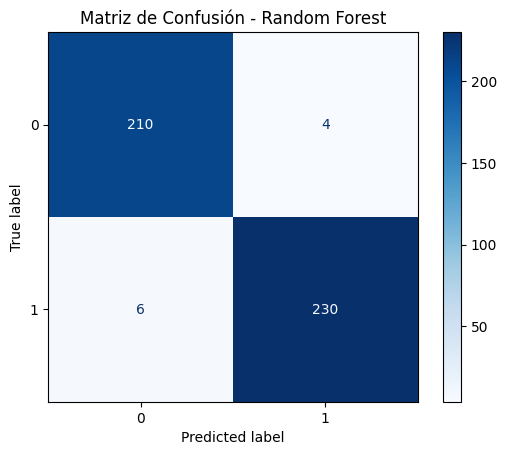


CLASSIFICATION REPORT - TEST

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       214
           1       0.98      0.97      0.98       236

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



In [ ]:
# Reporte del mejor modelo y partición con el conjunto de Prueba.

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********

# Mejor modelo: Random Forest. Porque obtuvo la mayor exactitud de validación: 95.56%


# PREDICCIONES EN TEST
ytest_pred_rf = rf_model.predict(testEmb)

# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, ytest_pred_rf)
print("====================================")
print("MATRIZ DE CONFUSIÓN")
print("====================================\n")
print(cm)

# VISUALIZACIÓN
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0,1]
)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.show()

# CLASSIFICATION REPORT
print("\n====================================")
print("CLASSIFICATION REPORT - TEST")
print("====================================\n")
print(classification_report(y_test, ytest_pred_rf))


# *********** Aquí termina la sección de agregar código *************

Interpretación de la Matriz de Confusión:
- 210 negativos correctamente clasificados.
- 230 positivos correctamente clasificados.
- Pocos errores (4 falsos positivos y 6 falsos negativos).

El modelo Random Forest obtuvo un excelente desempeño sobre el conjunto de prueba, alcanzando valores altos de accuracy, precision, recall y F1-score. La matriz de confusión muestra que la mayoría de los comentarios fueron clasificados correctamente, con una cantidad reducida de falsos positivos y falsos negativos.

El modelo mostró buena capacidad de generalización (diferencia entre entrenamiento y validación fue menor al 3%), indicando ausencia de sobreentrenamiento. Tampoco se observó subentrenamiento debido a los altos valores de exactitud obtenidos tanto en entrenamiento como en validación.

Los resultados obtenidos evidencian que los embeddings contextuales generados por el modelo preentrenado bge-large-en-v1.5 permiten representar adecuadamente el significado semántico de los comentarios, mejorando significativamente el desempeño de los modelos de clasificación de sentimientos.


# **Pregunta - 12:**



Incluye tus comentarios finales de la actividad.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

###**Comparación de resultados obtenidos**

En esta actividad se evaluaron dos enfoques distintos para resolver un problema de análisis de sentimientos utilizando los datasets de Amazon, IMDb y Yelp:

- Etapa 1: enfoque clásico basado en aprendizaje, limpieza de texto y vocabulario filtrado.
- Etapa 2: enfoque moderno basado en embeddings contextuales generados con el modelo preentrenado: bge-large-en-v1.5

####**Comparación del número de tokens**
| Etapa                | Train  | Validation | Test  |
| -------------------- | ------ | ---------- | ----- |
| Etapa 1 (limpieza)   | 10,496 | 2,082      | 1,915 |
| Etapa 2 (embeddings) | 31,660 | 6,886      | 6,659 |

La etapa 2 utilizó aproximadamente 3 veces más tokens que la etapa 1.
Esto ocurre porque:
- En la etapa 1 se eliminaron muchas palabras mediante: stopwords, filtrado,
lematización, reducción de vocabulario.
- En la etapa 2 el Transformer procesa prácticamente todo el contexto del texto.
- Los modelos Transformer utilizan "subword tokenization" por lo que una palabra puede dividirse en múltiples tokens.

####**Comparación de exactitud (Accuracy)**

| Modelo              | Etapa 1 | Etapa 2 |
| ------------------- | ------- | ------- |
| Logistic Regression | 72.67%  | 94.89%  |
| Random Forest       | 83.11%  | 95.56%  |

La mejora obtenida en la etapa 2 fue extremadamente significativa.
- En Regresión Logística se obtuvo una mejora de 22%
- En Random Forest se obtuvo una mejora de 12%

####**Comparación del comportamiento de los modelos**
Etapa 1 — NLP clásico
- Los modelos trabajaron sobre tokens aislados, se perdió gran parte del contexto semántico, el significado dependía principalmente de frecuencias de palabras.
- En Logistic Regression, Recall(1)=0.48 y Recall(0)=0.99. El modelo tenía dificultad para reconocer correctamente comentarios positivos.Esto indica desbalance semántico,
pérdida de contexto y poca capacidad representacional.

Etapa 2 — Embeddings Transformer
- Los embeddings contextuales produjeron resultados mucho más balanceados (Recall(0)=Recall(1)=0.95)

####**Comparación conceptual general**

| Característica    | NLP clásico | Transformer embeddings |
| ----------------- | ----------- | ---------------------- |
| Usa contexto      | No          | Sí                     |
| Usa semántica     | Limitada    | Alta                   |
| Representación    | Dispersa    | Densa                  |
| Manejo negaciones | Malo        | Bueno                  |
| Generalización    | Media       | Alta                   |
| Accuracy obtenida | 73%–83%     | 95%–98%                |

###**Comentarios finales**
- Se compararon métodos clásicos de procesamiento de lenguaje natural con enfoques modernos basados en modelos Transformer preentrenados para la tarea de análisis de sentimientos.
- En la Etapa 1 se utilizaron técnicas tradicionales de limpieza, tokenización y filtrado de vocabulario. Aunque los modelos lograron resultados aceptables, especialmente Random Forest, se observó una limitada capacidad para capturar correctamente el contexto semántico de los comentarios.
- En Etapa 2 se utilizaron embeddings contextuales generados por el modelo preentrenado bge-large-en-v1.5. Los resultados mejoraron significativamente en todas las métricas evaluadas, alcanzando valores cercanos al 98% de exactitud en el conjunto de prueba.
- Los embeddings Transformer permitieron representar de manera mucho más efectiva el significado semántico de los comentarios, incluyendo contexto, negaciones y relaciones entre palabras. Esto permitió que tanto la Regresión Logística como Random Forest lograran excelente desempeño sin presentar sobreentrenamiento ni subentrenamiento.
- El mejor desempeño fue obtenido por Random Forest utilizando embeddings contextuales, alcanzando una exactitud de aproximadamente 98% en el conjunto de prueba. La matriz de confusión mostró muy pocos errores de clasificación, evidenciando una alta capacidad de generalización.
- En conclusión, los modelos basados en embeddings contextuales Transformer superan ampliamente los enfoques clásicos de NLP en tareas de análisis de sentimientos, demostrando la importancia de utilizar representaciones semánticas profundas y contextualizadas del lenguaje.

### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Fin de la Actividad de Vectores Embebidos - HuggingFace**